# Guided Numeric Exploration — White Noise & Human Postural Stability
_Does VR fool your balance system? Force-plate sway under vision and sound conditions_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [maulikgajera/white-noise-and-human-postural-stability](https://www.kaggle.com/datasets/maulikgajera/white-noise-and-human-postural-stability)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.
Indented lines signify code is part of a larger function or loop.

***


# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Outcomes](#Univariate)** <br>
**4. [Visual Condition Effects](#Visual)** <br>
**5. [Sound (White Noise) Effects](#Sound)** <br>
**6. [Protocol and Interactions](#Interactions)** <br>
**7. [Subject-Level Structure](#Subjects)** <br>
**8. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
Standing still requires continuous corrections from vision, vestibular, and proprioceptive input. This table records **25 healthy adults** on a foam surface, each contributing force-plate trials under **NonVR** (eyes open / eyes closed) and **VR** (static vs head-tracked dynamic scenes), crossed with **silence vs steady white noise**. Outcomes are clinical sway measures: `AreaOfEllipse` (95% COP ellipse area) and `VelocityRMS_AP` (anterior–posterior velocity RMS).

Numeric `Visual` codes in the clean CSVs do not perfectly match the data-card legend, so I decode condition labels from `Filename` tokens (`EO`/`EC`/`VS`/`VH`, `SN`/`SS`). Because each subject contributes many trials, this is a **repeated-measures** design — person baseline sway is a first-class source of variance.

Interpretations after each plot are working notes about associations in this table, not clinical advice.


# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)


/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances, PCA), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.


In [2]:
# Read and Peak at Data
KAGGLE_SLUG = "maulikgajera/white-noise-and-human-postural-stability"
FILES = {
    "NonVR": "NonVR_protocol_clean.csv",
    "VR": "VR_protocol_clean.csv",
}
EXPECTED_COLS = [
    "Filename", "ID", "Surface", "Visual", "Environment", "Sound",
    "FilterUp", "Trial", "AreaOfEllipse", "VelocityRMS_AP",
]
VISUAL_MAP = {"EO": "Eyes Open", "EC": "Eyes Closed", "VS": "VR Static", "VH": "VR Dynamic"}
SOUND_MAP = {"SN": "White Noise", "SS": "Silence"}


def resolve_dataset_root() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for name in FILES.values():
            hits = list(kaggle_root.rglob(name))
            if hits:
                return hits[0].parent
    local_dir = Path("data") / "white-noise-postural"
    if all((local_dir / n).exists() for n in FILES.values()):
        return local_dir
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    for name in FILES.values():
        assert (root / name).exists() or any(root.rglob(name)), f"missing {name} under {root}"
    # handle nested download layout
    for name in FILES.values():
        hits = list(root.rglob(name))
        assert hits, f"expected {name} under {root}"
        return hits[0].parent
    raise AssertionError(f"dataset root not found under {root}")


root = resolve_dataset_root()
print("Dataset root:", root)

frames = []
for protocol, basename in FILES.items():
    hits = list(Path(root).rglob(basename))
    assert hits, f"missing {basename}"
    part = pd.read_csv(hits[0], low_memory=False)
    missing = set(EXPECTED_COLS) - set(part.columns)
    assert not missing, f"{basename} missing cols: {sorted(missing)}"
    part = part.copy()
    part["protocol"] = protocol
    frames.append(part)

df = pd.concat(frames, ignore_index=True)
assert len(df) == 400, f"expected 400 trials, got {len(df)}"
assert df["ID"].nunique() == 25, f"expected 25 subjects, got {df['ID'].nunique()}"

# Decode conditions from Filename (card warns numeric Visual codes disagree with legend)
toks = df["Filename"].astype(str).str.split("_")
df["visual_code"] = toks.str[2]
df["sound_code"] = toks.str[3]
unknown_v = set(df["visual_code"]) - set(VISUAL_MAP)
unknown_s = set(df["sound_code"]) - set(SOUND_MAP)
assert not unknown_v, f"unexpected visual tokens: {unknown_v}"
assert not unknown_s, f"unexpected sound tokens: {unknown_s}"
df["visual_label"] = df["visual_code"].map(VISUAL_MAP)
df["sound_label"] = df["sound_code"].map(SOUND_MAP)
assert df["AreaOfEllipse"].notna().all() and df["VelocityRMS_AP"].notna().all()

unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
print("Missing Values:", df.isnull().sum().sum())
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Protocols:", df["protocol"].value_counts().to_dict())
print("Visual labels:", df["visual_label"].value_counts().to_dict())
print("Sound labels:", df["sound_label"].value_counts().to_dict())


  0%|          | 0.00/10.4k [00:00<?, ?B/s]

100%|██████████| 10.4k/10.4k [00:00<00:00, 9.47MB/s]

Extracting files...


Dataset root: /Users/nicapotato/.cache/kagglehub/datasets/maulikgajera/white-noise-and-human-postural-stability/versions/1
Missing Values: 0
Dataframe Dimension: 400 Rows, 15 Columns
Protocols: {'NonVR': 200, 'VR': 200}
Visual labels: {'Eyes Closed': 101, 'VR Dynamic': 100, 'VR Static': 100, 'Eyes Open': 99}
Sound labels: {'White Noise': 200, 'Silence': 200}


**Code Explanation and Reasoning:** <br>
I load both clean protocol CSVs, tag `protocol`, and concat to 400 trials. Condition labels come from `Filename` tokens rather than the numeric `Visual`/`Sound` columns, because the data card documents a coding mismatch. Asserts lock subject count, row count, and token vocab.


In [3]:
df.sample(5, random_state=7)


,Filename,ID,Surface,Visual,Environment,Sound,FilterUp,Trial,AreaOfEllipse,VelocityRMS_AP,protocol,visual_code,sound_code,visual_label,sound_label
265,forceplate_391_VH_SN_FO_2_synced,391,1,2,2,3,10,2,17.776570,3.596788,VR,VH,SN,VR Dynamic,White Noise
65,forceplate_391_EC_SN_FO_2_synced,391,1,0,2,3,10,2,22.535532,4.959251,NonVR,EC,SN,Eyes Closed,White Noise
120,forceplate_661_EC_SN_FO_1_synced,661,1,0,2,3,10,1,18.564918,3.567236,NonVR,EC,SN,Eyes Closed,White Noise
132,forceplate_747_EC_SS_FO_3_synced,747,1,0,2,0,10,3,10.417570,1.499793,NonVR,EC,SS,Eyes Closed,Silence
378,forceplate_957_VH_SS_FO_1_synced,957,1,2,2,0,10,1,45.485396,5.693891,VR,VH,SS,VR Dynamic,Silence


In [4]:
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Unique", ascending=False))
df[["AreaOfEllipse", "VelocityRMS_AP"]].describe().T.round(3)


Dataframe Dimension: 400 Rows, 15 Columns


,Column,Unique,Null
0,Filename,400,0
8,AreaOfEllipse,400,0
9,VelocityRMS_AP,400,0
1,ID,25,0
11,visual_code,4,0
13,visual_label,4,0
3,Visual,3,0
7,Trial,3,0
5,Sound,2,0
10,protocol,2,0


,count,mean,std,min,25%,50%,75%,max
AreaOfEllipse,400.0,18.053,15.480,2.572,10.024,15.691,22.737,233.300
VelocityRMS_AP,400.0,3.186,3.961,0.929,1.942,2.830,3.679,57.687


**Interpretation** <br>
Each row is one force-plate trial. Surface / Environment / FilterUp are constant in these clean files (foam protocol), so the experimental contrast lives in vision, sound, protocol, and person (`ID`). Sway outcomes are continuous and right-skewed — a few large-sway outliers will pull means.


# **3. Univariate Outcomes:** <a id="Univariate"></a>


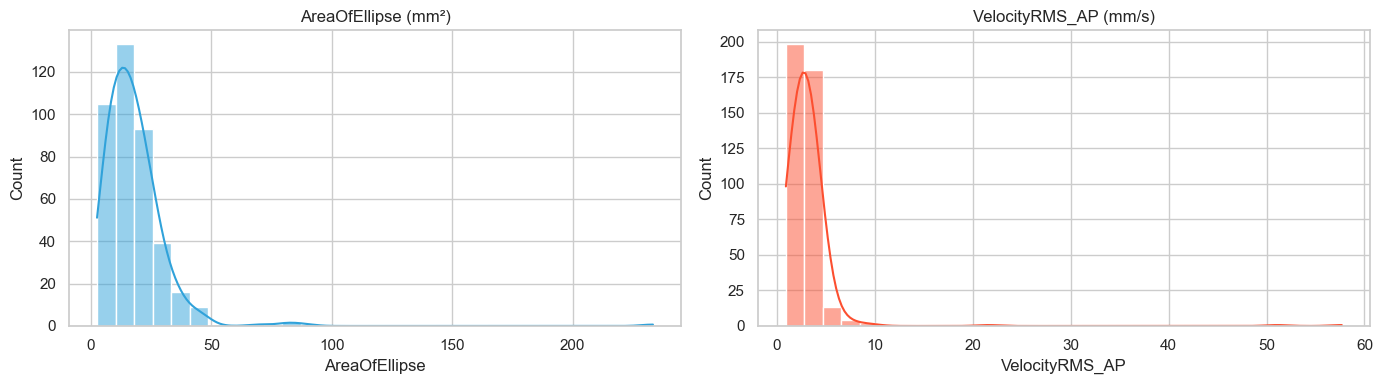

Pearson r(area, velocity): 0.784


In [5]:
f, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["AreaOfEllipse"], bins=30, kde=True, ax=ax[0], color="#30a2da")
ax[0].set_title("AreaOfEllipse (mm²)")
sns.histplot(df["VelocityRMS_AP"], bins=30, kde=True, ax=ax[1], color="#fc4f30")
ax[1].set_title("VelocityRMS_AP (mm/s)")
plt.tight_layout()
plt.show()

print("Pearson r(area, velocity):", round(df["AreaOfEllipse"].corr(df["VelocityRMS_AP"]), 3))


**How to Interpret:** <br>
Both sway measures are positive and skewed. A strong positive correlation would mean trials with large ellipse area also show fast AP corrections; a weak correlation would mean the two clinical summaries capture partly distinct instability patterns.


# **4. Visual Condition Effects:** <a id="Visual"></a>


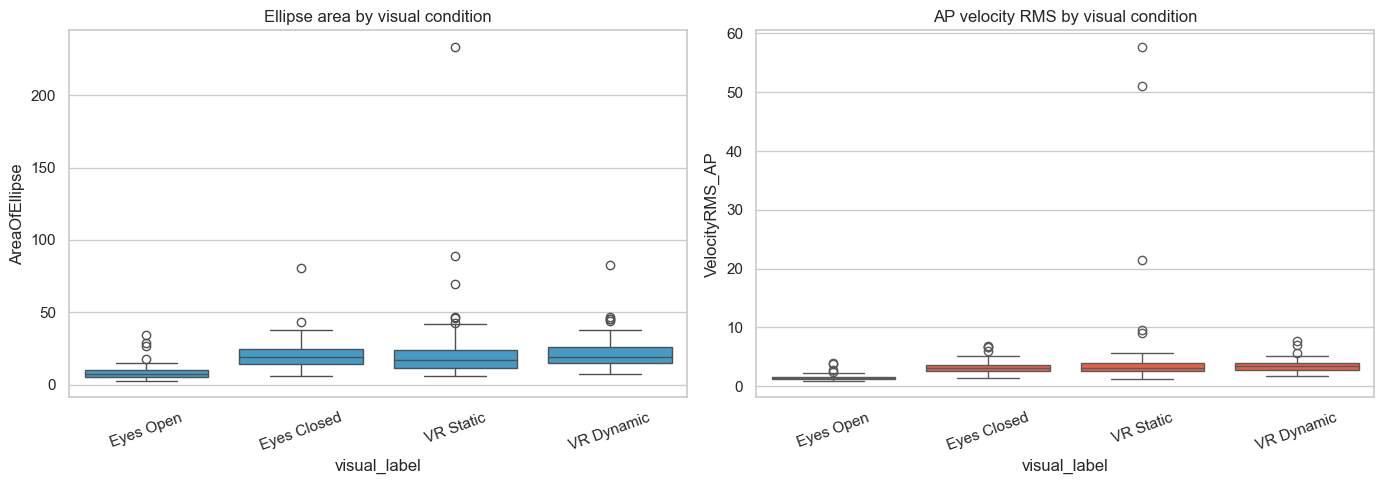

AreaOfEllipse                     VelocityRMS_AP                   
                      mean median    std count           mean median   std count
visual_label                                                                    
Eyes Open             8.33   7.09   5.03    99           1.51   1.39  0.48    99
Eyes Closed          20.25  19.24   9.54   101           3.28   3.06  1.02   101
VR Static            21.81  17.07  24.63   100           4.52   3.19  7.51   100
VR Dynamic           21.70  19.22  10.73   100           3.42   3.38  0.97   100

In [6]:
order_v = ["Eyes Open", "Eyes Closed", "VR Static", "VR Dynamic"]
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="visual_label", y="AreaOfEllipse", order=order_v, ax=ax[0], color="#30a2da")
ax[0].set_title("Ellipse area by visual condition")
ax[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=df, x="visual_label", y="VelocityRMS_AP", order=order_v, ax=ax[1], color="#fc4f30")
ax[1].set_title("AP velocity RMS by visual condition")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

display(
    df.groupby("visual_label")[["AreaOfEllipse", "VelocityRMS_AP"]]
    .agg(["mean", "median", "std", "count"])
    .reindex(order_v)
    .round(2)
)


**How to Interpret:** <br>
Compare Eyes Open vs Eyes Closed as the real-world baseline, then ask whether VR Static / VR Dynamic sit closer to open-eyes stability or closed-eyes instability. Higher medians and longer whiskers mean worse or more variable postural control under that visual input.


# **5. Sound (White Noise) Effects:** <a id="Sound"></a>


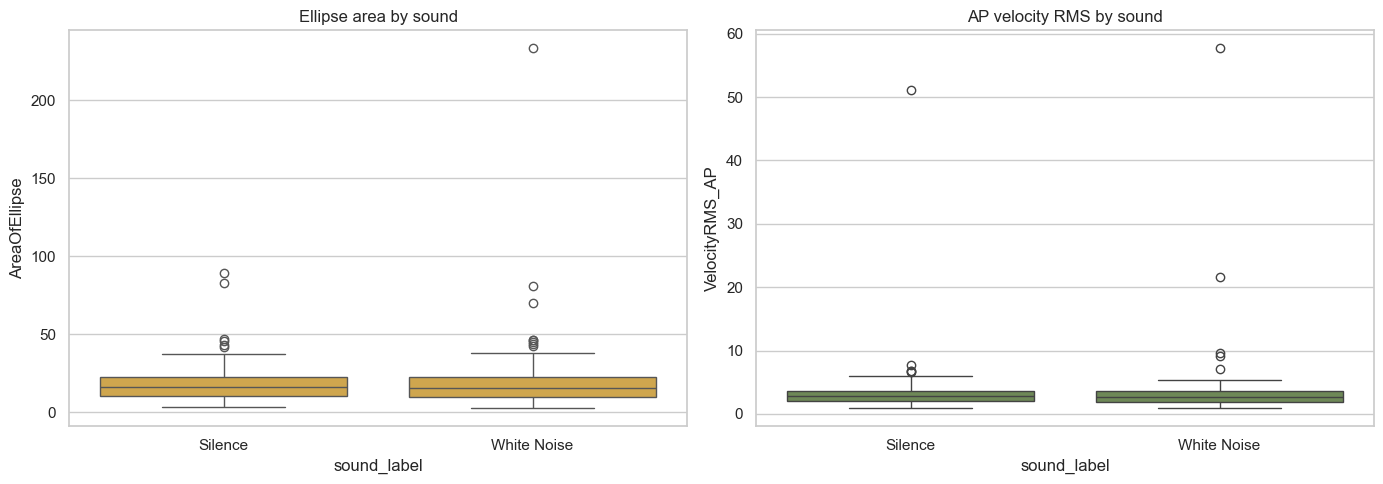

Mean subject delta Area (Noise - Silence): 0.452
Mean subject delta Velocity (Noise - Silence): 0.081
Paired t Area p: 0.6846 | Velocity p: 0.8332


In [7]:
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="sound_label", y="AreaOfEllipse", order=["Silence", "White Noise"], ax=ax[0], color="#e5ae38")
ax[0].set_title("Ellipse area by sound")
sns.boxplot(data=df, x="sound_label", y="VelocityRMS_AP", order=["Silence", "White Noise"], ax=ax[1], color="#6d904f")
ax[1].set_title("AP velocity RMS by sound")
plt.tight_layout()
plt.show()

# Paired-ish contrast: subject means under each sound
sub = (
    df.groupby(["ID", "sound_label"])[["AreaOfEllipse", "VelocityRMS_AP"]]
    .mean()
    .reset_index()
)
wide_a = sub.pivot(index="ID", columns="sound_label", values="AreaOfEllipse")
wide_v = sub.pivot(index="ID", columns="sound_label", values="VelocityRMS_AP")
assert set(wide_a.columns) >= {"Silence", "White Noise"}
delta_a = (wide_a["White Noise"] - wide_a["Silence"]).dropna()
delta_v = (wide_v["White Noise"] - wide_v["Silence"]).dropna()
print("Mean subject delta Area (Noise - Silence):", round(delta_a.mean(), 3))
print("Mean subject delta Velocity (Noise - Silence):", round(delta_v.mean(), 3))
stat_a = stats.ttest_rel(wide_a.loc[delta_a.index, "White Noise"], wide_a.loc[delta_a.index, "Silence"])
stat_v = stats.ttest_rel(wide_v.loc[delta_v.index, "White Noise"], wide_v.loc[delta_v.index, "Silence"])
print("Paired t Area p:", round(stat_a.pvalue, 4), "| Velocity p:", round(stat_v.pvalue, 4))


**How to Interpret:** <br>
Subject-mean deltas remove some person baseline before testing noise vs silence. A near-zero mean delta with large p-value suggests white noise is not a dominant main effect in this table; a consistent signed delta would support an independent auditory influence on sway.


# **6. Protocol and Interactions:** <a id="Interactions"></a>


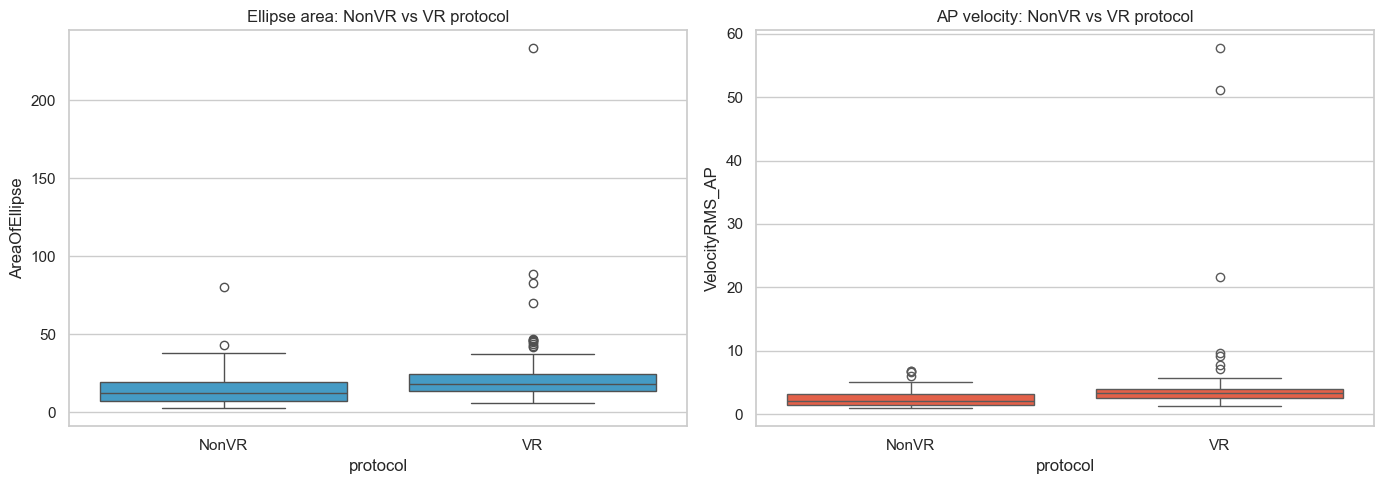

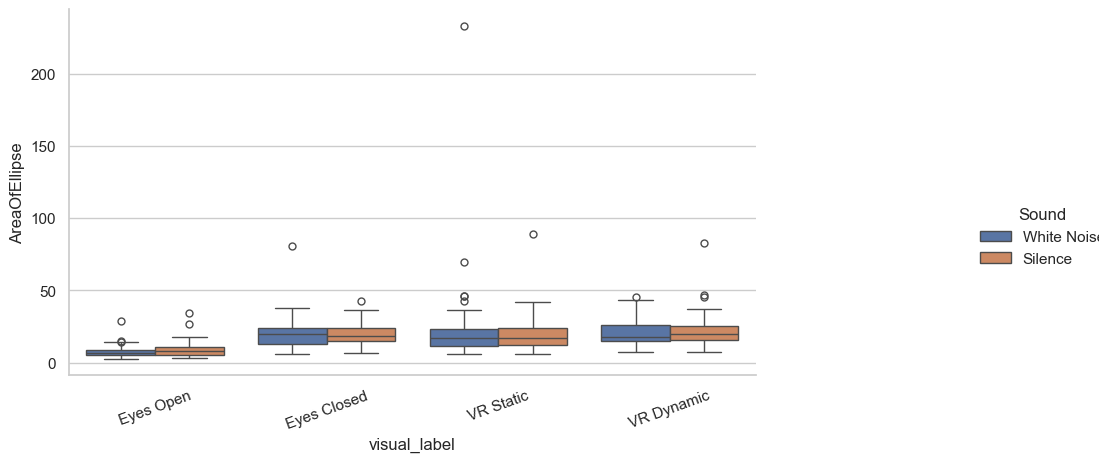

AreaOfEllipse  VelocityRMS_AP
protocol visual_label sound_label                               
NonVR    Eyes Closed  Silence              20.11            3.39
                      White Noise          20.38            3.17
         Eyes Open    Silence               8.95            1.56
                      White Noise           7.73            1.45
VR       VR Dynamic   Silence              22.47            3.44
                      White Noise          20.96            3.40
         VR Static    Silence              19.61            4.14
                      White Noise          24.11            4.91

In [8]:
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="protocol", y="AreaOfEllipse", ax=ax[0], color="#30a2da")
ax[0].set_title("Ellipse area: NonVR vs VR protocol")
sns.boxplot(data=df, x="protocol", y="VelocityRMS_AP", ax=ax[1], color="#fc4f30")
ax[1].set_title("AP velocity: NonVR vs VR protocol")
plt.tight_layout()
plt.show()

# Interaction: visual × sound on ellipse area
g = sns.catplot(
    data=df, x="visual_label", y="AreaOfEllipse", hue="sound_label",
    kind="box", order=order_v, height=4.5, aspect=1.8,
)
g.set_xticklabels(rotation=20)
g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_loc("center left")
g._legend.set_title("Sound")
plt.subplots_adjust(right=0.82)
plt.show()

display(
    df.groupby(["protocol", "visual_label", "sound_label"])[["AreaOfEllipse", "VelocityRMS_AP"]]
    .mean()
    .round(2)
)


**How to Interpret:** <br>
Protocol boxes ask whether the VR session overall produces more sway than NonVR. The visual × sound interaction plot asks whether noise helps (or hurts) differently under eyes-closed vs dynamic VR. Parallel box pairs imply additive effects; a wedge implies interaction.


# **7. Subject-Level Structure:** <a id="Subjects"></a>


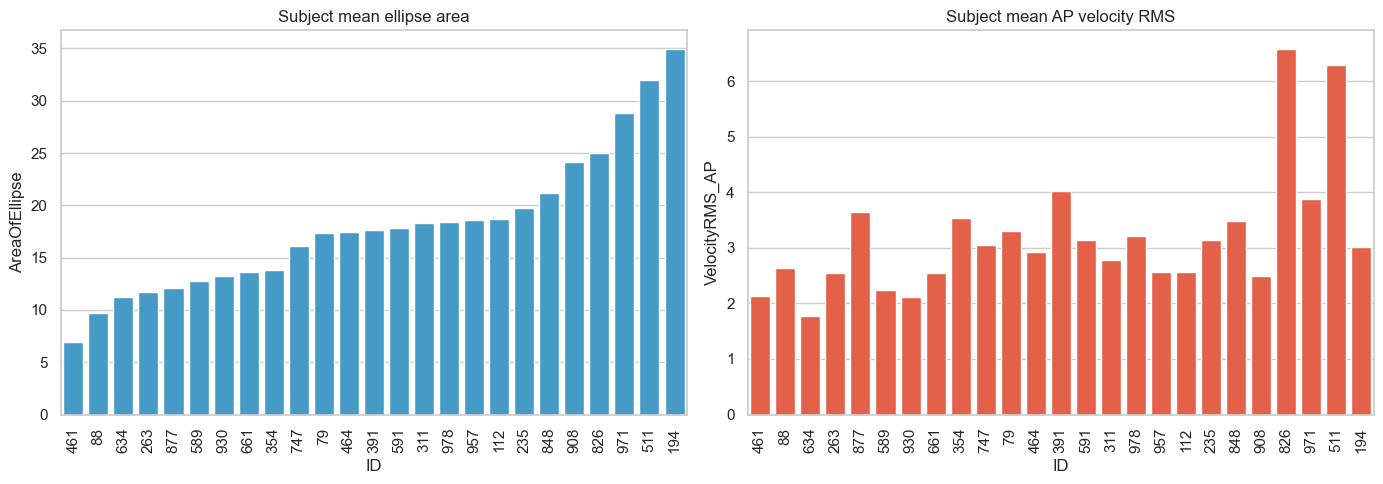

Area variance — overall: 239.62 | between-subject (of means): 46.08 | mean within-subject: 207.77
Share of mean-level between variance vs within: 0.182


In [9]:
subj = df.groupby("ID")[["AreaOfEllipse", "VelocityRMS_AP"]].mean().sort_values("AreaOfEllipse")
f, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=subj.index.astype(str), y=subj["AreaOfEllipse"], ax=ax[0], color="#30a2da")
ax[0].set_title("Subject mean ellipse area")
ax[0].tick_params(axis="x", rotation=90)
sns.barplot(x=subj.index.astype(str), y=subj["VelocityRMS_AP"], ax=ax[1], color="#fc4f30")
ax[1].set_title("Subject mean AP velocity RMS")
ax[1].tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

# Variance components (rough): between vs within subject for AreaOfEllipse
overall_var = df["AreaOfEllipse"].var(ddof=1)
between = df.groupby("ID")["AreaOfEllipse"].mean().var(ddof=1)
within = df.groupby("ID")["AreaOfEllipse"].var(ddof=1).mean()
print("Area variance — overall:", round(overall_var, 2),
      "| between-subject (of means):", round(between, 2),
      "| mean within-subject:", round(within, 2))
print("Share of mean-level between variance vs within:", round(between / (between + within), 3))


**How to Interpret:** <br>
Large between-subject spread means some people are chronically sway-heavy. Any predictive model should **group cross-validation folds by `ID`** so a person's baseline does not leak from train into validation. Within-subject variance is the experimental signal across conditions.


# **8. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A repeated-measures force-plate experiment: 25 subjects × NonVR and VR visual protocols × silence/white-noise, with ellipse area and AP velocity RMS as sway outcomes.

**Working takeaways:** <br>
- Decode vision/sound from `Filename`; do not trust numeric Visual codes alone.
- Compare real eyes-open/closed against VR static/dynamic to judge whether VR is a usable visual reference.
- White-noise main effects may be small relative to vision and person; check subject-mean deltas.
- Person baselines are large — treat `ID` as a clustering unit for any modeling.

**Open follow-ups:** <br>
- Mixed-effects models with random intercepts for `ID`.
- Trial-replicate reliability within condition.
- Outlier trials (extreme VR sway) — sensor artifact vs genuine instability?
